In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

/home/suchith/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Model(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_hidden_layers):
        super(Model, self).__init__()

        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.num_hidden_layers = num_hidden_layers

        self.in_layer = nn.Linear(self.in_dim, self.hidden_dim)
        self.hidden_layers = nn.Sequential(
            *[nn.Linear(self.hidden_dim, self.hidden_dim) for _ in range(self.num_hidden_layers)]
        )
        self.out_layer = nn.Linear(self.hidden_dim, 1)

    def forward(self, x):
        h = self.in_layer(x)
        h = self.hidden_layers(h)
        o = self.out_layer(h)
        return o

In [3]:
model = Model(
    in_dim=5,
    hidden_dim=20,
    num_hidden_layers=2
)
model

Model(
  (in_layer): Linear(in_features=5, out_features=20, bias=True)
  (hidden_layers): Sequential(
    (0): Linear(in_features=20, out_features=20, bias=True)
    (1): Linear(in_features=20, out_features=20, bias=True)
  )
  (out_layer): Linear(in_features=20, out_features=1, bias=True)
)

In [4]:
with torch.no_grad():
    outs = model(torch.rand((5000, 5)))

print(outs.shape)

torch.Size([5000, 1])


<Axes: ylabel='Density'>

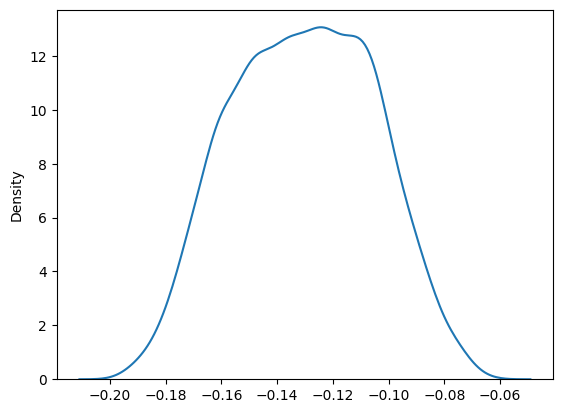

In [5]:
sns.kdeplot(outs.squeeze().numpy())